<a href="https://colab.research.google.com/github/harshelke180502/Intro_to_ML_2025_Course_projects/blob/all_p1%2Cp2%26p3_together/P1_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assignment: Understanding Loss Functions in Machine Learning <font color='red'>**[30 points]**</font>



## Objective
The goal of this assignment is to understand different loss functions used in machine learning. Loss functions measure the difference between predicted and actual values and play a crucial role in optimizing machine learning models.

## Instructions
1. **Implement the following loss functions:**
   - Squared Loss
   - Absolute Loss
   - Huber Loss https://en.wikipedia.org/wiki/Huber_loss
   - Logistic Loss
   - Hinge Loss https://en.wikipedia.org/wiki/Hinge_loss

2. **Dataset:**
   - Generate a larger dataset with at least 100 samples where `y_true` consists of binary labels (0 or 1), and `y_pred` is a continuous array with values between 0 and 1 representing predicted probabilities.
   - You may use NumPy to generate the dataset.
   
3. **Visualization:**
   - Use Matplotlib to visualize how each loss function behaves.
   - Specifically, create the following plots:
     - **3D Plot for Each Loss Function**:
       - X-axis: `y_true` (actual labels)
       - Y-axis: `y_pred` (predicted probabilities)
       - Z-axis: Corresponding loss value
     - Generate separate 3D plots for each loss.
   
## Deliverables
- Python functions for all loss functions.
- A script to generate and test the dataset.
- 3D plots comparing the above 5 loss functions given in **#1** <font color='red'>**[5 points for each loss]**</font>
- A short explanation of the behavior of each loss function and when it is most suitable. <font color='red'>**[1 point for each loss]**</font>

## Hints
- Use `numpy.meshgrid()` to create a grid of `y_true` and `y_pred` values.
- Use `matplotlib.pyplot.plot_surface()` to generate 3D visualizations.
- Ensure numerical stability by clipping probability values in Log Loss.



In [8]:
!pip install ucimlrepo


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ucimlrepo import fetch_ucirepo








**COMPUTED THE FOLLOWING LOSS FUNCTIONS :**

Squared Loss: Measures the squared difference between actual and predicted values, penalizing larger errors more heavily.

Absolute Loss: Computes the absolute difference between actual and predicted values, treating all errors equally regardless of magnitude.

Huber Loss: Combines squared loss for small errors and absolute loss for large errors, making it more robust to outliers.

Logistic Loss: Used in binary classification, it measures how far predicted probabilities deviate from actual labels using the logarithm function.

Hinge Loss:  It penalizes predictions that are not confidently on the correct side of the decision boundary.

In [10]:

def squared_loss(y_true, y_pred):
    return (y_true - y_pred) ** 2

def absolute_loss(y_true, y_pred):
    return np.abs(y_true - y_pred)

def huber_loss(y_true, y_pred, delta=1.0):
    diff = y_true - y_pred
    return np.where(np.abs(diff) <= delta, 0.5 * diff ** 2, delta * (np.abs(diff) - 0.5 * delta))

def logistic_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)  # To avoid log(0) errors
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def hinge_loss(y_true, y_pred):
    y_true = 2 * y_true - 1  # Convert 0, 1 to -1, 1 for hinge loss calculation
    return np.maximum(0, 1 - y_true * (2 * y_pred - 1))

**Utilized the ionosphere dataset from the UCI Website.It consists of 351 instances with 34 continuous features, representing radar signal attributes. The target variable has two classes: "g" (good signals, labeled as 1) and "b" (bad signals, labeled as 0), indicating whether the signal is indicative of a structure in the ionosphere.**

In [11]:
ionosphere = fetch_ucirepo(id=52)
ionosphere_df = pd.DataFrame(ionosphere.data.features)
ionosphere_df['target'] = ionosphere.data.targets
ionosphere_df['target'] = ionosphere_df['target'].map({'g': 1, 'b': 0})

# Extract y_true (binary labels)
y_true = ionosphere_df['target'].values

# Generate y_pred (random probabilities between 0 and 1)
np.random.seed(42)
y_pred = np.random.rand(len(y_true))  # Random predictions between 0 and 1

In [12]:
num_points = 100
y_true_grid = np.linspace(0, 1, num_points)
y_pred_grid = np.linspace(0, 1, num_points)
Y_true, Y_pred = np.meshgrid(y_true_grid, y_pred_grid)
Y_true,Y_pred

(array([[0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ],
        [0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ],
        [0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ],
        ...,
        [0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ],
        [0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ],
        [0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
         1.        ]]),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.01010101, 0.01010101, 0.01010101, ..., 0.01010101, 0.01010101,
         0.01010101],
        [0.02020202, 0.02020202, 0.02020202, ..., 0.02020202, 0.02020202,
         0.02020202],
        ...,
        [0.97979798, 0.97979798, 0.97979798, ..., 0.97979798, 0.97979798,
         0.97979798],
        [0.9

In [13]:
loss_functions = {
    "Squared Loss": squared_loss,
    "Absolute Loss": absolute_loss,
    "Huber Loss": huber_loss,
    "Logistic Loss": logistic_loss,
    "Hinge Loss": hinge_loss
}


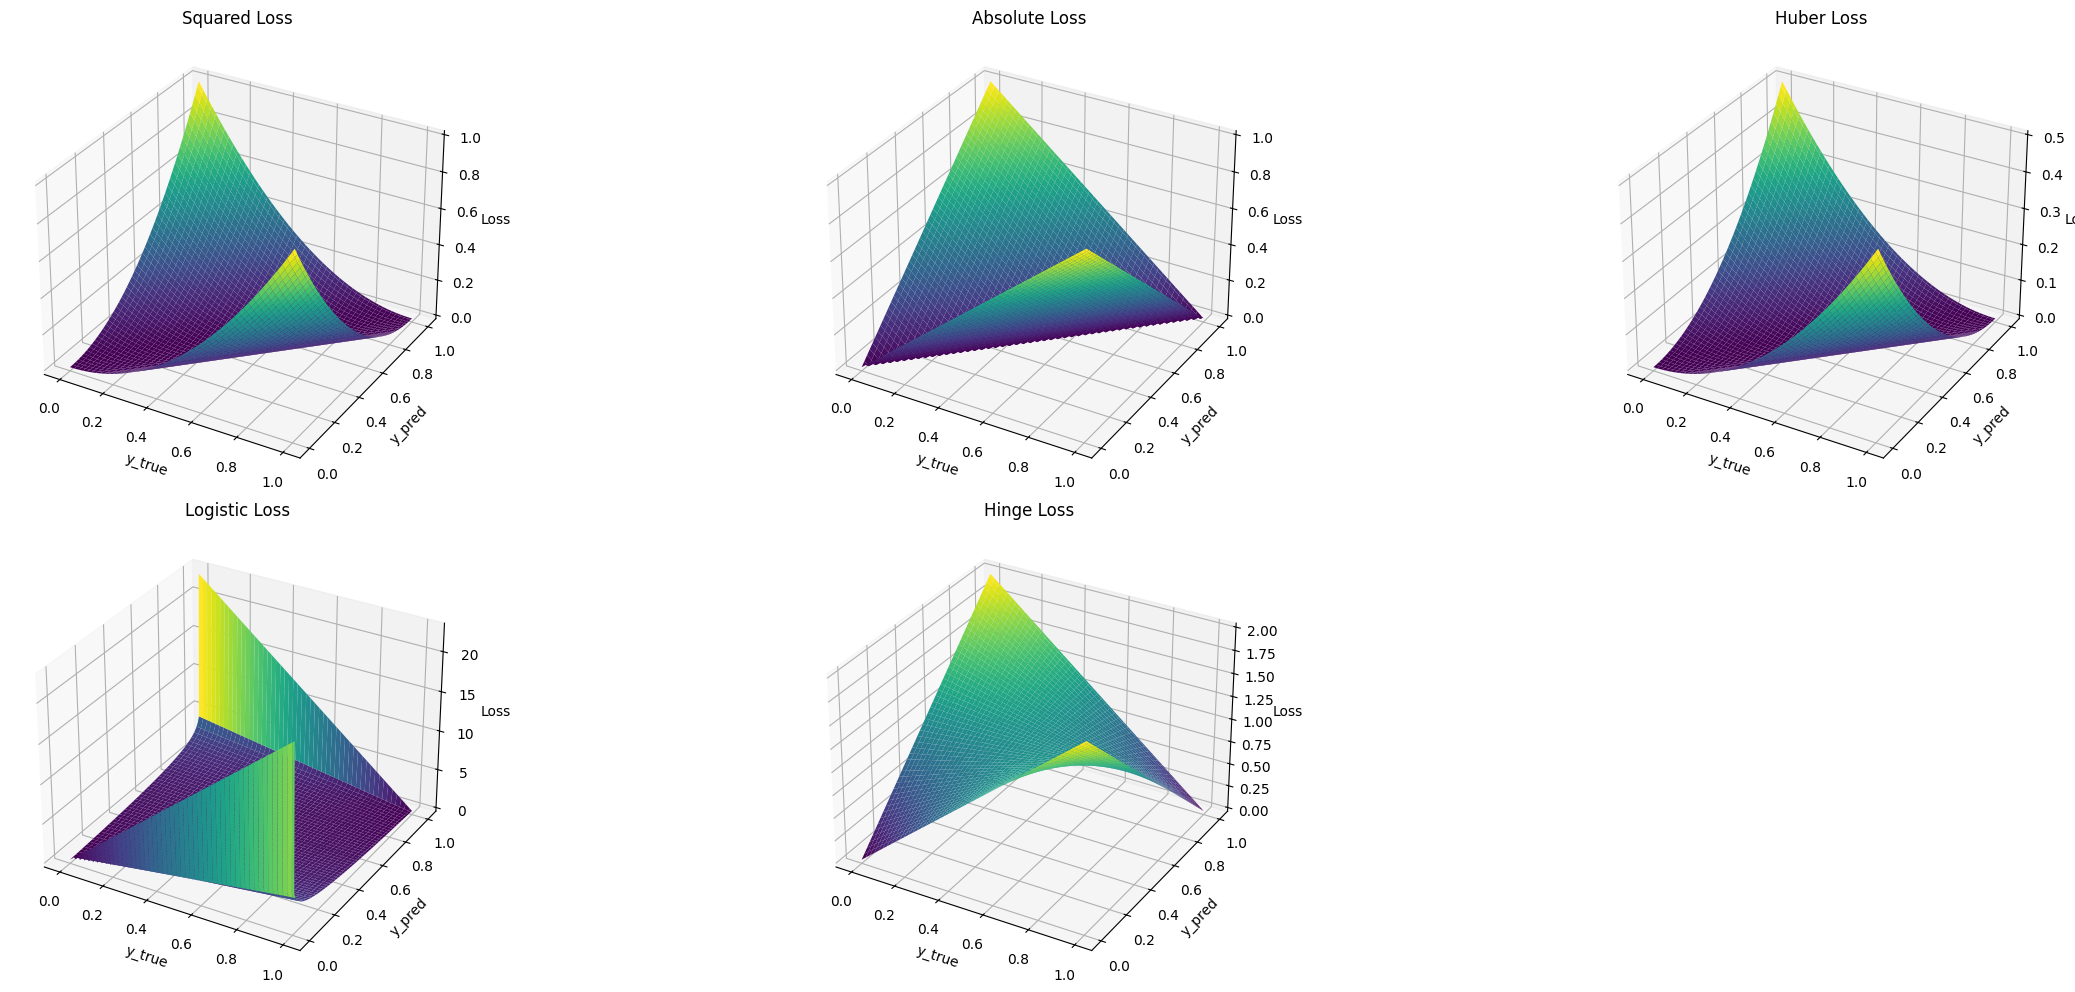

In [14]:
fig = plt.figure(figsize=(25, 10))

for i, (name, func) in enumerate(loss_functions.items(), 1):
    Z = func(Y_true, Y_pred)  # Calculate loss for grid points
    ax = fig.add_subplot(2, 3, i, projection='3d')
    ax.plot_surface(Y_true, Y_pred, Z, cmap='viridis')
    ax.set_title(name)
    ax.set_xlabel("y_true")
    ax.set_ylabel("y_pred")
    ax.set_zlabel("Loss")

plt.tight_layout()
plt.show()

**Differences and the behaviour of the above portrayed loss functions are as follows:**

1. Squared Loss:


- Behavior: Parabolic shape which increases quadratically with error
- It works perfectly for regression problems where outliers are rare and large errors should be heavily penalized
- It is highly sensitive to outliers due to squaring of errors
-Moreover it shows the steepest surface among all losses and shows highest peaks at extreme errors.




2. Absolute Loss:


- Behavior: Linearly increases with error magnitude
- Best for: Regression with potential outliers as it's more robust than squared loss
- It is less sensitive to outliers than squared loss
- It depicts more moderate peaks compared to squared loss
- Shows uniform penalty for all errors



3. Huber Loss:


- Behavior: It combines squared loss near zero and absolute loss for larger errors
- It works best for regression problems where we dont want robustness to outliers while maintaining MSE benefits
- Good compromise between squared and absolute loss.
Also, provides a smooth transition between L1 and L2 loss.
-It showcases a smoother transition between regions
- It contains more moderate peaks than squared loss



4. Logistic Loss:


- Behavior: Logarithmic shape, approaches infinity at extremes
-  It is best for binary classification problems where probability estimates are needed
-  Provides probability estimates between 0 and 1
-It projects a Sharp increase near boundaries and shows highest variation in loss values




5. Hinge Loss:


- Behavior: Linear penalty for misclassifications, zero loss for correct predictions
- It is most suitable for Support Vector Machines and margin-based classification
-It Shows a sharp vertex at the decision boundary
Doesn't provide probability estimates
- It projects a linear penalty for misclassifications,sharp transition at decision boundary and most sparse surface among all losses.